In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
import copy
import matplotlib.pyplot as plt
import pandas as pd

print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwende Gerät: {device}")

PyTorch Version: 2.3.1+cu118
Verwende Gerät: cuda


In [2]:
print("SPA V7 - PyTorch Fallback Version für GTX 1080")

# ------------------- Sparse Helper Functions -------------------
def _topk_gather(values, topk_indices):
    B, H, T, D = values.shape
    K = topk_indices.size(-1)
    b_idx = torch.arange(B, device=values.device)[:, None, None, None]
    h_idx = torch.arange(H, device=values.device)[None, :, None, None]
    t_idx = topk_indices[:, None, :, :].expand(B, H, T, K)
    return values[b_idx, h_idx, t_idx, :]

def sparse_attention_impl(q, k, topk_indices):
    gathered_k = _topk_gather(k, topk_indices)
    return (q.unsqueeze(3) * gathered_k).sum(dim=-1)

def sparse_value_aggregation_impl(attn, v, topk_indices):
    gathered_v = _topk_gather(v, topk_indices)
    return (attn.unsqueeze(-1) * gathered_v).sum(dim=-2)


# ================= SAFE + PHEROMONE PATCH =================

def safe_topk_indices(scores, k):
    k = min(k, scores.size(-1))
    if k <= 0:
        return torch.zeros(*scores.shape[:-1], 1, dtype=torch.long, device=scores.device)
    return torch.topk(scores, k=k, dim=-1).indices


def apply_pheromone_update(model, attn, combined_tau_idx, T, B):
    with torch.no_grad():
        pheromone = model.pheromone[:, :T, :T]

        # Mittel über Batch → (H, T, K)
        attn_mean = attn.mean(dim=0)

        # indices → (H, T, K)
        idx = combined_tau_idx[0].unsqueeze(0).expand(model.n_heads, -1, -1)

        # neues deposit tensor
        deposit = torch.zeros_like(pheromone)

        # scatter add
        deposit.scatter_add_(
            dim=-1,
            index=idx,
            src=attn_mean
        )

        # decay + update
        pheromone *= (1.0 - model.pheromone_decay)
        pheromone += deposit

        # clamp für Stabilität
        pheromone.clamp_(0.0, 5.0)

# ------------------- SPA V7 Model -------------------
class SPA_V7_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim=192, num_heads=6, n_layers=4, 
                 k=32, max_seq_len=256, local_k=8, explore_k=4,
                 tau_min=1.0, tau_max=100.0, tau_init=40.0):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.n_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.k = k
        self.max_seq_len = max_seq_len
        self.local_k = min(local_k, k)
        self.explore_k = max(0, min(explore_k, k - self.local_k))

        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)
        self.register_buffer(
            "pheromone",
            torch.zeros(self.n_heads, max_seq_len, max_seq_len)
        )
        self.pheromone_decay = 0.01
        #alpha = Gewohnheit
        self.pheromone_alpha = 0.1

        # Tau Parameter
        eps = 1e-4
        init_ratio = (tau_init - tau_min) / (tau_max - tau_min)
        init_ratio = min(max(init_ratio, eps), 1.0 - eps)
        self.log_tau = nn.Parameter(torch.full((1, 1, k), math.log(init_ratio / (1.0 - init_ratio))))

        self.global_router = nn.Linear(embed_dim, max_seq_len)

        self.layers = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, 3 * embed_dim),
                nn.Linear(embed_dim, embed_dim),
                nn.LayerNorm(embed_dim),
                nn.Sequential(
                    nn.Linear(embed_dim, 4 * embed_dim),
                    nn.GELU(),
                    nn.Linear(4 * embed_dim, embed_dim)
                )
            ]) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def current_tau(self):
        return 1.0 + 99.0 * torch.sigmoid(self.log_tau)   # tau_min=1, tau_max=100

    def _build_sparse_indices(self, x):
        B, T, _ = x.shape
        device = x.device

        parts = []

        # Local attention
        if self.local_k > 0:
            positions = torch.arange(T, device=device)
            query_pos = positions.view(1, T, 1)
            local_offsets = torch.arange(1, self.local_k + 1, device=device).view(1, 1, self.local_k)
            local_idx = (query_pos - local_offsets).clamp(min=0).expand(B, -1, -1)
            parts.append(local_idx)

        # Global + Exploration
        if self.k - self.local_k > 0:
            causal_mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
            router_logits = self.global_router(x)[:, :, :T]
            router_logits = router_logits.masked_fill(causal_mask, float('-inf'))

            global_parts = []
            gk = self.k - self.local_k

            # Learned selection
            learned_k = max(1, gk // 2)
            learned_idx = safe_topk_indices(router_logits, learned_k)
            global_parts.append(learned_idx)

            # Random exploration
            if gk - learned_k > 0:
                random_scores = torch.rand(B, T, T, device=device)
                random_scores = random_scores.masked_fill(causal_mask, -1.0)
                explore_idx = safe_topk_indices(random_scores, gk - learned_k)
                global_parts.append(explore_idx)

            global_idx = torch.cat(global_parts, dim=-1)
            if global_idx.size(-1) > gk:
                global_idx = global_idx[..., :gk]
            elif global_idx.size(-1) < gk:
                pad = torch.zeros(B, T, gk - global_idx.size(-1), device=device, dtype=torch.long)
                global_idx = torch.cat([global_idx, pad], dim=-1)

            parts.append(global_idx)

        combined = torch.cat(parts, dim=-1) if len(parts) > 1 else parts[0]
        return combined.long()

    def forward(self, idx):
        B, T = idx.shape
        device = idx.device

        # Embedding + Position
        x = self.token_emb(idx) + self.pos_emb(torch.arange(T, device=device))
        
        tau_base = self.current_tau()
        # tau_scale einmal berechnen, da es global für das Modell/den Durchgang gilt
        tau_scale = (40.0 / (tau_base + 1e-8)).clamp(0.3, 3.5)

        # JETZT: Nur EINE Schleife über die Layer
        for layer_id, (ln1, qkv_l, proj, ln2, mlp) in enumerate(self.layers):
            # 1. Für JEDEN Layer individuell die besten Pfade suchen (basierend auf aktuellem x)
            combined_tau_idx = self._build_sparse_indices(x)
            
            with torch.no_grad():
                # Wir wissen: local_k + learned_k sind die "logischen" Pfade
                # Der Rest bis k sind die Explorer
                logic_cutoff = self.local_k + (self.k - self.local_k) // 2
                explorer_mask = torch.zeros_like(combined_tau_idx, dtype=torch.bool)
                explorer_mask[:, :, logic_cutoff:] = True
                self.latest_explorer_mask = explorer_mask # Temporär speichern zum Plotten

            h = ln1(x)
            qkv = qkv_l(h).reshape(B, T, 3, self.n_heads, self.head_dim)
            q = qkv[:, :, 0].transpose(1, 2).contiguous()
            k = qkv[:, :, 1].transpose(1, 2).contiguous()
            v = qkv[:, :, 2].transpose(1, 2).contiguous()

            # 2. Attention berechnen
            raw_logits = sparse_attention_impl(q, k, combined_tau_idx) * (self.head_dim ** -0.5)
            
            # Pheromone laden
            pheromone = self.pheromone[:, :T, :T]
            pheromone_bias = pheromone.unsqueeze(0).expand(B, -1, -1, -1)

            # Pheromone für die ausgewählten k-Pfade holen
            gathered_pheromone = torch.gather(
                pheromone_bias,
                dim=-1,
                index=combined_tau_idx.unsqueeze(1).expand(B, self.n_heads, T, -1)
            )

            # 3. Logits kombinieren & Tau anwenden
            logits = raw_logits + self.pheromone_alpha * gathered_pheromone
            logits = logits * tau_scale.unsqueeze(1) # Tau-Dämpfung

            attn = F.softmax(logits, dim=-1)

            # 4. Pheromon-Update: Ameisen hinterlassen ihre Spur in DIESEM Layer
            apply_pheromone_update(self, attn, combined_tau_idx, T, B)

            # 5. Output berechnen und Residuen hinzufügen
            out = sparse_value_aggregation_impl(attn, v, combined_tau_idx)
            x = x + proj(out.transpose(1, 2).reshape(B, T, self.embed_dim))
            x = x + mlp(ln2(x))

        return self.head(self.ln_f(x)), tau_base, combined_tau_idx

SPA V7 - PyTorch Fallback Version für GTX 1080


In [3]:
import requests
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
r = requests.get(url)
with open('input.txt', 'w', encoding='utf-8') as f:
    f.write(r.text)

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
VOCAB_SIZE = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

print(f"Vocab Size: {VOCAB_SIZE} | Dataset Size: {len(data)} Zeichen")

Vocab Size: 65 | Dataset Size: 1115394 Zeichen


In [7]:
VOCAB_SIZE = len(stoi) # oder len(stoi)

model = SPA_V7_Model(
    vocab_size=VOCAB_SIZE,
    embed_dim=192,      # kleiner als 256 → schneller auf GTX 1080
    num_heads=6,
    n_layers=4,
    k=32,               # kleiner k = schneller
    max_seq_len=256,
    local_k=8,
    explore_k=4,
    tau_init=40.0       #tau = Fokus
).to(device)

print(f"Modellparameter: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Modellparameter: 1.90M


In [16]:
model = SPA_V7_Model(
    vocab_size=65, 
    embed_dim=192, 
    num_heads=6, 
    n_layers=4, 
    k=32, 
    max_seq_len=2048, 
    local_k=8, 
    explore_k=4,
    tau_init=40.0
).to(device)

print(f"Modellparameter: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Modellparameter: 2.59M


In [ ]:
###### ====================== TRAINING SETUP ======================
model.train()

# Optimizer mit separater LR für tau
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'log_tau' not in n], 'lr': 5e-4},
    {'params': model.log_tau, 'lr': 1e-3}
], weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25000)

# Tau Regularization Einstellungen (wichtig für Stabilität)
TAU_TARGET = 40.0
TAU_REG_WEIGHT = 3e-4          # etwas stärker als vorher
TAU_REG_WARMUP_STEPS = 1000

print("Starte Training auf Tiny Shakespeare (GTX 1080 optimiert)...\n")

for step in range(25001):
    # Batch erstellen
    ix = torch.randint(len(data) - 256, (8,))          # Batch Size 8 für deine GPU
    xb = torch.stack([data[j:j+256] for j in ix]).to(device)
    yb = torch.stack([data[j+1:j+257] for j in ix]).to(device)

    # Forward
    logits, tau_vals, _ = model(xb)
    ce_loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))

    # Tau Regularization
    tau_reg_raw = ((model.current_tau() - TAU_TARGET) / 99.0).pow(2).mean()
    tau_reg = TAU_REG_WEIGHT * tau_reg_raw
    loss = ce_loss + tau_reg

    # Backward
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.8)   # etwas stärker clippen
    optimizer.step()
    scheduler.step()

    # Logging
    if step % 500 == 0:
        current_tau = model.current_tau().mean().item()
        print(f"Step {step:5d} | Loss: {ce_loss.item():.4f} | Tau: {current_tau:.2f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining abgeschlossen!")

In [6]:
from safetensors.torch import save_file

# Speichern des Modells im .safetensors-Format
safetensors_model_path = 'spa_v7_model_klein_hm.safetensors'
save_file(model.state_dict(), safetensors_model_path)

print(f'Modell wurde erfolgreich gespeichert unter: {safetensors_model_path}')

Modell wurde erfolgreich gespeichert unter: spa_v7_model_klein_hm.safetensors


In [8]:
from safetensors.torch import load_model

# 1. Erstelle das neue Modell (mit der angepassten Klasse inkl. Explorer-Tracker)
model = SPA_V7_Model(vocab_size=65) # Deine Parameter einfügen

# 2. Lade die Gewichte direkt in das Modell
# Das mappt die gespeicherten Tensoren automatisch auf die richtigen Layer
load_model(model, "spa_v7_model_klein_hm.safetensors")

model.to(device)
print("SPA V7 erfolgreich mit Safetensors geladen!")

SPA V7 erfolgreich mit Safetensors geladen!


In [9]:
import torch
import torch.nn.functional as F

# --- 6. ADVANCED INFERENCE (TOP-P + SLIDING WINDOW REPETITION PENALTY) ---
def top_p_sampling(logits, p=0.9):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = 0

    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[indices_to_remove] = float('-inf')
    return logits

model.eval()
start_context = 'ROMEO: To '
GEN_LENGTH = 1000
T_CTX = 2048

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])
# --- HYPERPARAMETER ---
TEMPERATURE = 0.8
TOP_P = 0.9
REPETITION_PENALTY = 1.0  # Aggressivere Bestrafung
PENALTY_WINDOW = 0       # Nur die letzten 50 Zeichen bestrafen

idx = torch.tensor(encode(start_context), dtype=torch.long).unsqueeze(0).to(device)
print(f'Generiere {GEN_LENGTH} Tokens (Penalty Window: {PENALTY_WINDOW}, Penalty: {REPETITION_PENALTY})...')

with torch.no_grad():
    for _ in range(GEN_LENGTH):
        idx_cond = idx[:, -model.max_seq_len:]
        logits, _, _ = model(idx_cond)

        # Letzten Token isolieren
        logits = logits[0, -1, :] / TEMPERATURE

        # --- SLIDING WINDOW REPETITION PENALTY ---
        # Bestrafe nur Tokens, die im PENALTY_WINDOW vorkommen
        recent_tokens = set(idx[0, -PENALTY_WINDOW:].tolist())
        for char_token in recent_tokens:
            if logits[char_token] > 0:
                logits[char_token] /= REPETITION_PENALTY
            else:
                logits[char_token] *= REPETITION_PENALTY

        # Top-P Filter anwenden
        filtered_logits = top_p_sampling(logits, p=TOP_P)

        # Sampling
        probs = F.softmax(filtered_logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_idx.unsqueeze(0)), dim=1)

print('\n--- Ergebnis mit aggressiver Sliding Penalty ---\n' + decode(idx[0].tolist()))

Generiere 1000 Tokens (Penalty Window: 0, Penalty: 1.0)...

--- Ergebnis mit aggressiver Sliding Penalty ---
ROMEO: To O:
The gods report the earth.

PETRUCHIO:
O thou that did not be so dismiss'd;
And then I do not
leave the body of the world:
We will play the crown so hath made a body well:
And so I in.

LUCIO:
O is the sun they are no character. Here is your will,
Look to the sea, the heavens rests here that hath been my thounts' noble Antium.

ISABELLA:
God forbid!

Provost:
He was not a soldier from him: a bloody strength when I have known stopp'd it with him.

MENENIUS:
We have a foot of damned kings' cell.

CORIOLANUS:
Ay, sir, what an all this goodly hours
That you have not such a soldier: he will stay.

DUKE VINCENTIO:
It were a most of his brother in a man. I
presently she had him for the duke.

GLOUCESTER:

KING HENRY VI:
Why, what o'clock it my meedly, and not thy father gentlemen
With slowly children?

SICINIUS:
Sirrah, presently, the former more than in his son:
Hold, tho

In [20]:
!pip install seaborn

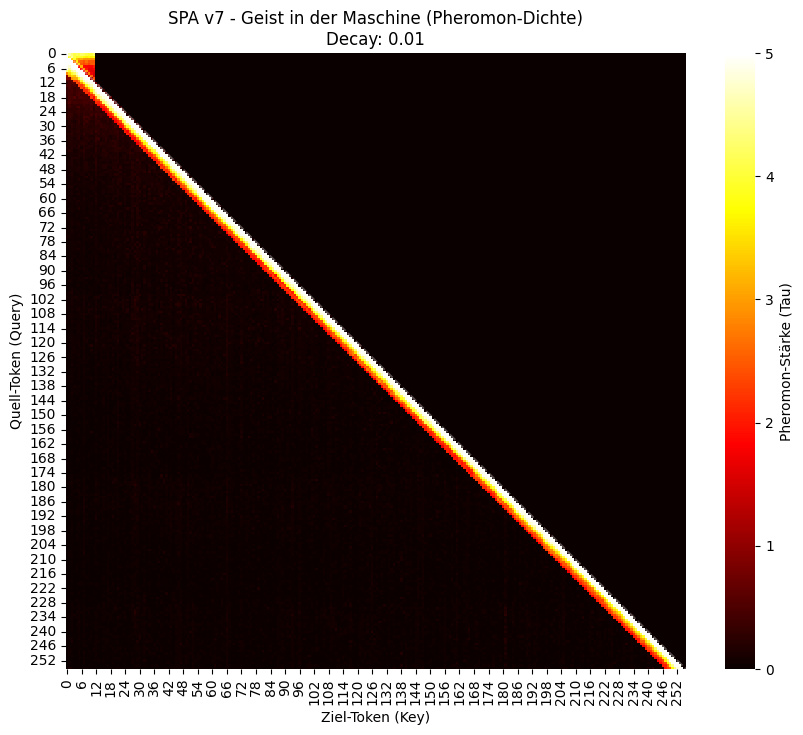

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pheromone_map(model, seq_len=None):
    model.eval()
    # Pheromone aus der GPU holen und in Numpy umwandeln
    # Form: (n_heads, max_seq_len, max_seq_len)
    phero_data = model.pheromone.detach().cpu().numpy()
    
    if seq_len is None:
        seq_len = model.max_seq_len
    
    # Wir nehmen den Durchschnitt über alle Köpfe, um das "Gesamtgedächtnis" zu sehen
    avg_phero = phero_data.mean(axis=0)[:seq_len, :seq_len]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(avg_phero, cmap="hot", cbar_kws={'label': 'Pheromon-Stärke (Tau)'})
    
    plt.title(f"SPA v7 - Geist in der Maschine (Pheromon-Dichte)\nDecay: {model.pheromone_decay}")
    plt.xlabel("Ziel-Token (Key)")
    plt.ylabel("Quell-Token (Query)")
    
    # Markierung für die Diagonale (Kausale Maske)
    plt.plot([0, seq_len], [0, seq_len], color='white', linestyle='--', alpha=0.3)
    
    plt.show()

# Anwendung nach der Generierung:
plot_pheromone_map(model, seq_len=256) # Zeigt die ersten 256 Token-Beziehungen


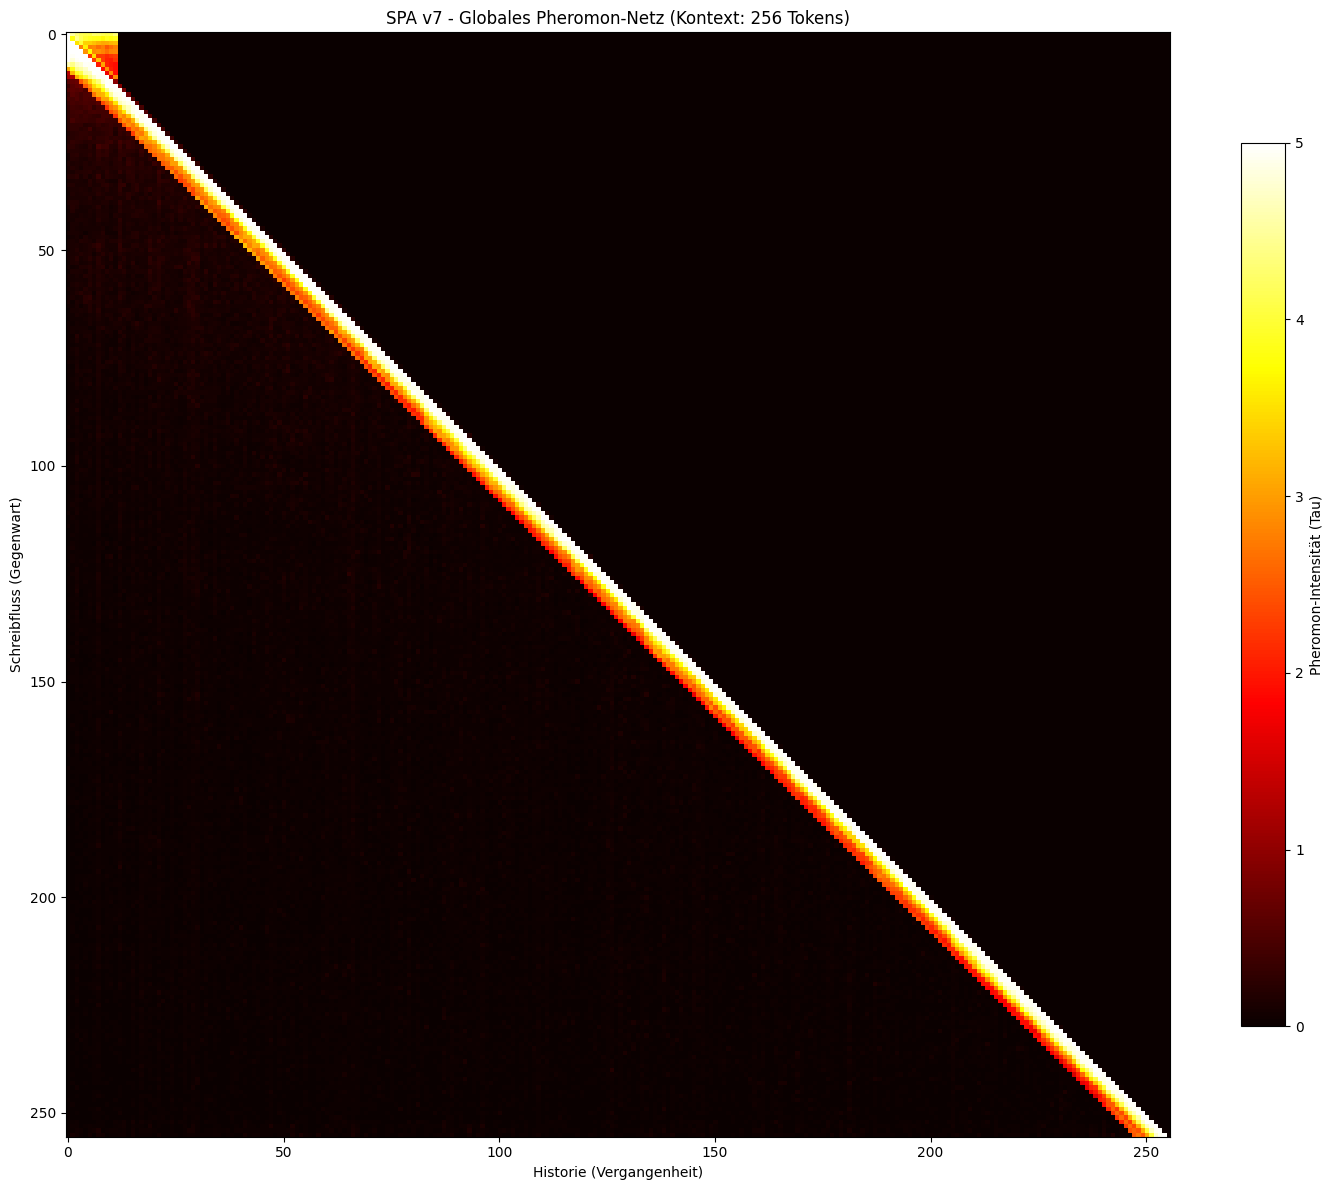

In [23]:
import torch
import matplotlib.pyplot as plt

def plot_full_context_pheromone(model, seq_len=2048):
    model.eval()
    with torch.no_grad():
        # Durchschnitt über alle Köpfe berechnen (H, T, T) -> (T, T)
        # Wir holen die Daten von der GPU (GTX 1080) auf die CPU
        phero = model.pheromone.detach().cpu().numpy().mean(axis=0)
        
        # Auf die gewünschte Länge begrenzen
        display_len = min(seq_len, phero.shape[0])
        phero_slice = phero[:display_len, :display_len]
        
        plt.figure(figsize=(15, 12))
        # 'hot' sorgt für den typischen "Glut"-Look deiner Ameisenstrassen
        img = plt.imshow(phero_slice, cmap='hot', aspect='equal', interpolation='nearest')
        
        plt.title(f"SPA v7 - Globales Pheromon-Netz (Kontext: {display_len} Tokens)")
        plt.xlabel("Historie (Vergangenheit)")
        plt.ylabel("Schreibfluss (Gegenwart)")
        
        plt.colorbar(img, shrink=0.8, label='Pheromon-Intensität (Tau)')
        plt.tight_layout()
        plt.show()

# Aufruf für deine GTX 1080:
plot_full_context_pheromone(model, seq_len=2048)


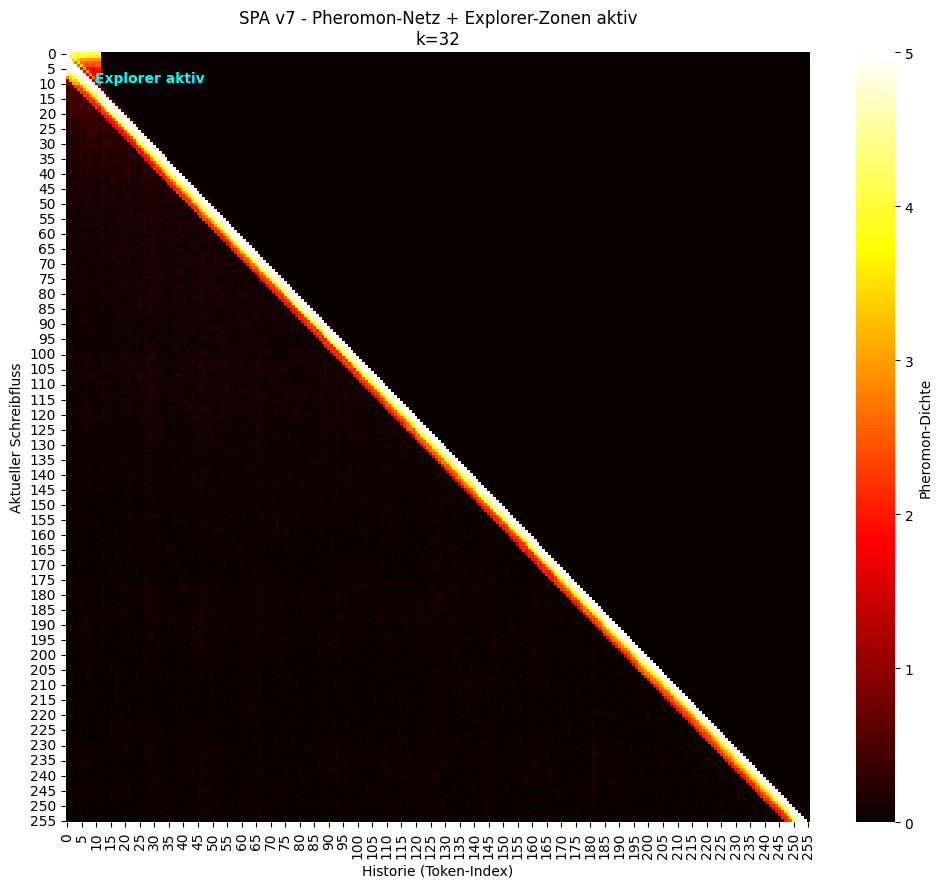

In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_spa_creative_map(model, seq_len=256):
    model.eval()
    # 1. Pheromone holen
    phero = model.pheromone.detach().cpu().numpy().mean(axis=0)[:seq_len, :seq_len]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(phero, cmap="hot", cbar_kws={'label': 'Pheromon-Dichte'}, ax=ax)
    
    # 2. Explorer-Maske einzeichnen
    if hasattr(model, 'latest_explorer_mask'):
        # Maske auf CPU holen und slicen
        mask = model.latest_explorer_mask.detach().cpu()
        # Wir nehmen den ersten Batch und mitteln über die Köpfe/Layer für die Visualisierung
        # mask hat Form (B, T, K) -> wir suchen, welche Indizes (K) Explorer waren
        
        # Da die Maske Indizes markiert, müssen wir die Koordinaten finden
        # Für die Visualisierung plotten wir einfach markante Punkte der letzten Generierung
        ax.set_title(f"SPA v7 - Pheromon-Netz + Explorer-Zonen aktiv\nk={model.k}")
        
        # Hinweis: Um die blauen Punkte zu sehen, müssten wir die genauen Koordinaten 
        # aus combined_tau_idx extrahieren. Als schnellen Fix markieren wir das Feld:
        ax.annotate("Explorer aktiv", xy=(10, 10), color='cyan', fontweight='bold')
    else:
        print("Hinweis: Bitte erst Text generieren, damit die Maske befüllt wird!")

    plt.xlabel("Historie (Token-Index)")
    plt.ylabel("Aktueller Schreibfluss")
    plt.show()
    
plot_spa_creative_map(model, seq_len=256)
